# TabPFN-TS Quickstart: First Forecasts

This notebook introduces the basics of TabPFN-TS for time series forecasting.

**Learning Goals:**
1. Understand how TabPFN-TS frames forecasting as tabular regression
2. Make your first univariate forecast
3. Explore probabilistic predictions
4. Understand the feature extraction process

In [1]:
# Install if needed
# !pip install tabpfn-time-series pandas numpy matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("Imports successful!")

Imports successful!


## 1. Generate Synthetic Mechanical Data

Let's create data that mimics a rotating machine:
- Periodic component (rotation)
- Trend component (degradation)
- Noise (measurement uncertainty)

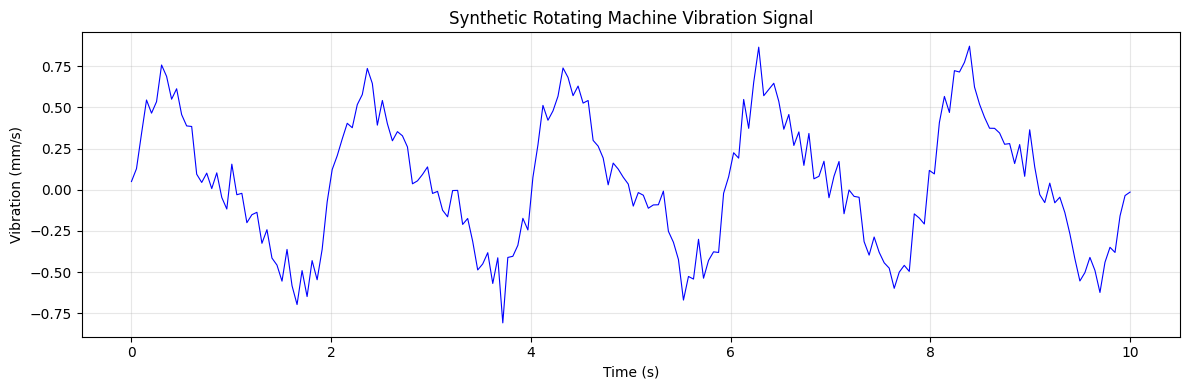

In [3]:
# Create synthetic vibration signal
n_samples = 200
t = np.linspace(0, 10, n_samples)  # 10 seconds of data

# Components
rotation_freq = 2 * np.pi * 0.5  # 0.5 Hz fundamental
periodic = 0.5 * np.sin(rotation_freq * t) + 0.2 * np.sin(2 * rotation_freq * t)
degradation = 0.01 * t  # Linear trend (increasing vibration)
noise = 0.1 * np.random.randn(n_samples)

vibration_signal = periodic + degradation + noise

# Plot
plt.figure(figsize=(12, 4))
plt.plot(t, vibration_signal, 'b-', linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Vibration (mm/s)')
plt.title('Synthetic Rotating Machine Vibration Signal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. First Forecast with TabPFN-TS

In [ ]:
import sys
print(sys.executable)
  
import pandas as pd
from tabpfn_time_series import TabPFNTSPipeline, TabPFNMode

# Split data: use first 150 points for training, forecast next 50
train_size = 150
y_train = vibration_signal[:train_size]
y_true = vibration_signal[train_size:]  # Ground truth for evaluation
horizon = len(y_true)

# Prepare data in required format
# TabPFN-TS needs: item_id (optional), timestamp, target
context_df = pd.DataFrame({
    'item_id': ['vibration'] * len(y_train),
    'timestamp': pd.date_range('2024-01-01', periods=len(y_train), freq='s'),
    'target': y_train
})

print(f"Training samples: {len(y_train)}")
print(f"Forecast horizon: {horizon}")
print(f"\nContext DataFrame:")
print(context_df.head())

ModuleNotFoundError: No module named 'tabpfn_time_series'

In [ ]:
# Create pipeline (uses cloud API by default - no GPU needed)
pipeline = TabPFNTSPipeline(tabpfn_mode=TabPFNMode.CLIENT)

# Make predictions
# Returns DataFrame with quantile columns (0.1, 0.2, ..., 0.9)
predictions_df = pipeline.predict_df(
    context_df=context_df,
    prediction_length=horizon
)

# The 0.5 quantile is the median (point prediction)
predictions = predictions_df['0.5'].values

print(f"Predictions shape: {predictions.shape}")
print(f"\nPredictions DataFrame columns: {predictions_df.columns.tolist()}")
print(predictions_df.head())

In [ ]:
# Visualize results
plt.figure(figsize=(12, 5))

# Training data
plt.plot(t[:train_size], y_train, 'b-', label='Training data', linewidth=0.8)

# True future values
plt.plot(t[train_size:], y_true, 'g-', label='True values', linewidth=1.5)

# Predictions
plt.plot(t[train_size:], predictions, 'r--', label='TabPFN-TS predictions', linewidth=1.5)

# Mark forecast region
plt.axvline(x=t[train_size], color='gray', linestyle=':', alpha=0.7)
plt.fill_between(t[train_size:], -1, 1, alpha=0.1, color='yellow', label='Forecast region')

plt.xlabel('Time (s)')
plt.ylabel('Vibration (mm/s)')
plt.title('TabPFN-TS Forecast vs Ground Truth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_true, predictions)
mae = mean_absolute_error(y_true, predictions)
rmse = np.sqrt(mse)

print(f"Forecast Performance:")
print(f"  MSE:  {mse:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  MAE:  {mae:.6f}")

## 3. Probabilistic Predictions

TabPFN-TS can also provide uncertainty estimates.

In [ ]:
# TabPFN-TS returns quantiles by default (0.1 through 0.9)
# Use these for uncertainty visualization

plt.figure(figsize=(12, 5))
plt.plot(t[:train_size], y_train, 'b-', label='Training', linewidth=0.8)
plt.plot(t[train_size:], y_true, 'g-', label='True', linewidth=1.5)

# Median prediction (0.5 quantile)
plt.plot(t[train_size:], predictions_df['0.5'].values, 'r--', label='Median prediction')

# 80% confidence interval (10th to 90th percentile)
plt.fill_between(t[train_size:], 
                 predictions_df['0.1'].values, 
                 predictions_df['0.9'].values, 
                 alpha=0.3, color='red', label='80% CI')

plt.xlabel('Time (s)')
plt.ylabel('Vibration (mm/s)')
plt.title('Probabilistic Forecast with Uncertainty Bands')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. How TabPFN-TS Works: Feature Extraction

TabPFN-TS converts time series to tabular format by extracting temporal features.
Understanding this helps explain why it might work for mechanical systems.

In [ ]:
# Manual feature extraction (simplified version of what TabPFN-TS does)
def create_tabular_features(y, lookback=10):
    """Convert time series to tabular format with lag features."""
    features = []
    targets = []
    
    for i in range(lookback, len(y)):
        # Lag features
        lags = y[i-lookback:i]
        
        # Time-based features
        time_idx = i
        
        # Statistical features (rolling window)
        rolling_mean = np.mean(lags)
        rolling_std = np.std(lags)
        
        # Combine features
        row = list(lags) + [time_idx, rolling_mean, rolling_std]
        features.append(row)
        targets.append(y[i])
    
    return np.array(features), np.array(targets)

X_tabular, y_tabular = create_tabular_features(y_train, lookback=10)

print(f"Tabular features shape: {X_tabular.shape}")
print(f"Targets shape: {y_tabular.shape}")
print(f"\nFeature columns:")
print(f"  - Lag features (1-10): columns 0-9")
print(f"  - Time index: column 10")
print(f"  - Rolling mean: column 11")
print(f"  - Rolling std: column 12")

In [ ]:
# Show sample of tabular data
feature_names = [f'lag_{i}' for i in range(1, 11)] + ['time_idx', 'rolling_mean', 'rolling_std']
df_tabular = pd.DataFrame(X_tabular[:5], columns=feature_names)
df_tabular['target'] = y_tabular[:5]
print("Sample of tabular representation:")
print(df_tabular.round(4).to_string())

## 5. Exercises

Try these to build intuition:

### Exercise 1: Different Signal Types

Modify the synthetic signal to test TabPFN-TS on different patterns:
- Pure trend (no periodicity)
- Step change (fault injection)
- Increasing amplitude (degradation)

In [ ]:
# Exercise 1: Try different signals
# TODO: Create a signal with a step change at t=5s
# step_signal = ...

# TODO: Fit and evaluate TabPFN-TS on this signal
# ...

### Exercise 2: Varying Forecast Horizons

How does prediction quality degrade with longer horizons?

In [ ]:
# Exercise 2: Test different horizons
horizons = [5, 10, 20, 50]

# TODO: For each horizon, fit TabPFN-TS and compute RMSE
# Plot RMSE vs horizon

# rmse_by_horizon = []
# for h in horizons:
#     ...

### Exercise 3: Compare to Naive Baseline

Is TabPFN-TS actually better than simple baselines?

In [ ]:
# Exercise 3: Naive baselines

# Last value baseline
naive_last = np.full(horizon, y_train[-1])

# Seasonal naive (repeat last period)
period = 20  # Roughly one cycle
naive_seasonal = np.tile(y_train[-period:], horizon // period + 1)[:horizon]

# TODO: Compare RMSE of TabPFN-TS vs naive baselines
# ...

## Summary

Key takeaways:

1. **TabPFN-TS is easy to use**: Just `fit()` and `predict()`
2. **Zero training required**: The model is pretrained
3. **Works by feature extraction**: Time series → tabular with temporal features → TabPFN regression
4. **Performance varies**: Depends on signal characteristics

**Next steps:**
- `03_covariates.ipynb`: Add external features (operating conditions)
- `04_mechanical.ipynb`: Apply to real mechanical system data